# Projeto Semantix

## Previsão de demissões e admissões

O objetivo deste projeto é desenvolver um modelo de **Machine Learning** capaz de prever se uma movimentação trabalhista corresponde a uma **admissão ou demissão**.

A base de dados utilizada contendo informações sobre movimentações trabalhistas no Brasil e foi obtida no site [**Data Basis**](https://data-basis.org/dataset/562b56a3-0b01-4735-a049-eeac5681f056?table=95106d6f-e36e-4fed-b8e9-99c41cd99ecf)

O projeto contempla as etapas de **extração e análise dos dados, limpeza, tratamento e preparação das variáveis, treinamento e avaliação do modelo e, por fim, realização das previsões**.

A base original é bastante extensa e contém dados de **2007 a 2019**. Para avaliar a capacidade do modelo de realizar previsões sobre dados futuros, será adotada uma abordagem temporal: os dados de **2007 a 2017** serão utilizados para treinamento e teste do modelo, enquanto os dados de **2018 e 2019** serão reservados exclusivamente para realizar previsões e avaliar seu desempenho em períodos posteriores aos utilizados no treinamento.

# 1. Carregamento e preparação dos dados

## 1.1 Carregando a base

In [1]:
import basedosdados as bd
import pandas as pd
import numpy as np
from google.cloud import bigquery
import time

# Plotar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Tratamentos e métricas
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Modelos de Machine Learning
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Salva o modelo em um arquivo externo
import joblib

In [2]:
# mostra todas as colunas do dataframe
pd.set_option("display.max_columns", None)

No código abaixo, são baixados dados referentes ao período de **2007 a 2019**. Embora o modelo seja treinado utilizando apenas os dados de **2007 a 2017**, os dados de **2018 e 2019** também são carregados para que passem pelo mesmo processo de limpeza.

Após a conclusão da limpeza, os dados de 2018 e 2019 serão armazenados em um arquivo `.csv` separado e, em seguida, removidos do DataFrame. Esses dados permanecerão reservados e serão utilizados somente após a finalização e o treinamento do modelo, para realizar previsões sobre dados futuros.

In [3]:
# ID do projeto de faturamento no BigQuery (definido no Google Cloud)
billing_id = "projeto-semantix-505715"

# Nome do dataset e da tabela onde a amostra sera "congelada" (materializada) no
# proprio projeto. Isso resolve o problema de reprodutibilidade: em vez de sortear a
# amostra da tabela publica a cada execucao (que pode mudar de um dia para o outro,
# pois e mantida pela comunidade Base dos Dados), sorteamos UMA UNICA VEZ e gravamos
# o resultado permanentemente. Todas as execucoes futuras leem essa copia congelada.
dataset_amostra = "amostra_caged"
tabela_amostra = "amostra_admissoes_desligamentos"
tabela_amostra_completa = f"{billing_id}.{dataset_amostra}.{tabela_amostra}"

# Cria o dataset no projeto, caso ainda nao exista. Usamos o proprio bd.read_sql
# (em vez de um bigquery.Client() criado do zero) para reaproveitar a autenticacao
# que o basedosdados ja gerencia - um Client novo nao enxerga essas credenciais e
# tentaria usar Application Default Credentials, que nao estao configuradas aqui.
# location="US" e necessario porque a tabela publica `basedosdados.br_me_caged.microdados_antigos`
# fica armazenada na regiao "US", e o BigQuery exige que a tabela de destino fique
# na mesma regiao das tabelas consultadas na query.
bd.read_sql(query=f"CREATE SCHEMA IF NOT EXISTS `{billing_id}.{dataset_amostra}` OPTIONS(location='US')", billing_project_id=billing_id)

# Cria a tabela de amostra a partir da consulta original, mas SO SE ELA AINDA NAO EXISTIR.
# Na primeira vez que essa celula rodar, a amostra e sorteada e gravada permanentemente.
# Em todas as execucoes seguintes, o "IF NOT EXISTS" faz este comando nao fazer nada,
# entao a amostra usada e sempre a mesma - mesmo que a tabela publica original mude.
query_criacao = f"""
CREATE TABLE IF NOT EXISTS `{tabela_amostra_completa}` AS
SELECT * EXCEPT(linha)
FROM (
    SELECT
        dados.ano,
        dados.mes,
        dados.sigla_uf,
        dados.id_municipio,
        dados.admitidos_desligados,
        dados.tipo_estabelecimento,
        dados.tipo_movimentacao_desagregado,
        dados.faixa_emprego_inicio_janeiro,
        dados.tempo_emprego,
        dados.quantidade_horas_contratadas,
        dados.salario_mensal,
        dados.indicador_aprendiz,
        dados.indicador_portador_deficiencia,
        dados.cbo_2002,
        dados.grau_instrucao,
        dados.idade,
        dados.sexo,
        dados.raca_cor,

        ROW_NUMBER() OVER (
            PARTITION BY dados.ano
            ORDER BY FARM_FINGERPRINT(TO_JSON_STRING(dados))
        ) AS linha

    FROM `basedosdados.br_me_caged.microdados_antigos` AS dados

    WHERE dados.ano BETWEEN 2007 AND 2019
)
WHERE linha <= 10000
"""
bd.read_sql(query=query_criacao, billing_project_id=billing_id)

# A partir daqui, sempre se le da tabela congelada no projeto - nunca mais da
# tabela publica original. É isso que garante que os resultados do notebook (EDA,
# metricas dos modelos, texto de conclusao) sejam os mesmos em qualquer execucao futura.
df = bd.read_sql(query=f"SELECT * FROM `{tabela_amostra_completa}`", billing_project_id=billing_id)


Downloading: |                                                                                                        |
Downloading: |                                                                                                        |
Downloading: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|


In [4]:
df

,ano,mes,sigla_uf,id_municipio,admitidos_desligados,tipo_estabelecimento,tipo_movimentacao_desagregado,faixa_emprego_inicio_janeiro,tempo_emprego,quantidade_horas_contratadas,salario_mensal,indicador_aprendiz,indicador_portador_deficiencia,cbo_2002,grau_instrucao,idade,sexo,raca_cor
0,2009,5,RO,1100015,01,01,01,04,0.0,44,558.0,0,0,513205,06,22,02,02
1,2019,3,RO,1100015,01,03,02,01,0.0,44,1200.0,0,0,621005,06,37,01,04
2,2014,4,RO,1100015,01,03,02,01,0.0,44,724.0,0,0,623110,07,36,02,09
3,2016,12,RO,1100015,01,01,02,03,0.0,44,980.0,0,0,411005,07,23,02,02
4,2009,11,RO,1100015,01,01,02,01,0.0,44,465.0,0,0,521125,05,19,01,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129995,2018,9,DF,5300108,02,01,43,08,12.0,40,2249.0,0,0,411010,09,37,02,08
129996,2019,2,DF,5300108,02,01,90,08,45.0,44,1975.0,0,0,411010,09,34,01,08
129997,2018,10,DF,5300108,02,01,90,03,32.0,44,1583.0,0,0,521110,08,30,01,08
129998,2019,8,DF,5300108,02,01,90,05,16.0,44,1352.0,0,0,782220,02,26,01,08


## 1.2 Limpeza dos dados

Nesta etapa, será realizada a **limpeza da base de dados**, incluindo a identificação e o tratamento de valores ausentes ou inconsistentes, bem como a identificação e avaliação de possíveis outliers. O objetivo é garantir a **qualidade, consistência e confiabilidade dos dados** para as etapas seguintes do projeto.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130000 entries, 0 to 129999
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ano                             130000 non-null  Int64  
 1   mes                             130000 non-null  Int64  
 2   sigla_uf                        130000 non-null  object 
 3   id_municipio                    130000 non-null  object 
 4   admitidos_desligados            130000 non-null  object 
 5   tipo_estabelecimento            130000 non-null  object 
 6   tipo_movimentacao_desagregado   130000 non-null  object 
 7   faixa_emprego_inicio_janeiro    130000 non-null  object 
 8   tempo_emprego                   130000 non-null  float64
 9   quantidade_horas_contratadas    130000 non-null  Int64  
 10  salario_mensal                  130000 non-null  float64
 11  indicador_aprendiz              130000 non-null  object 
 12  indicador_portad

### Coluna `ano`

In [6]:
df['ano'].value_counts()

ano
2009    10000
2019    10000
2014    10000
2016    10000
2015    10000
2007    10000
2013    10000
2012    10000
2018    10000
2017    10000
2011    10000
2010    10000
2008    10000
Name: count, dtype: Int64

Nota-se que todos os anos possuem a mesma quantidade de registros, totalizando **10.000 amostras por ano**. Esse resultado já era esperado, pois, durante a extração dos dados, foi definido que seriam selecionadas 10.000 amostras para cada ano.

### Coluna `mes`

In [7]:
df['mes'].value_counts().sort_index()

mes
1     10917
2     10854
3     11520
4     10951
5     11095
6     10648
7     10805
8     11369
9     10782
10    10879
11    10282
12     9898
Name: count, dtype: Int64

Nota-se que a coluna `mes` já está representada como uma variável numérica, com valores variando de **1 a 12**, conforme o esperado. Portanto, **não é necessário realizar nenhum tratamento nessa etapa**.

### Coluna `sigla_uf`

In [8]:
df['sigla_uf'].value_counts().sort_index()

sigla_uf
AC      183
AL     1035
AM     1260
AP      175
BA     4829
CE     3153
DF     2201
ES     2931
GO     4542
MA     1177
MG    15276
MS     1798
MT     2892
PA     2248
PB      925
PE     3525
PI      683
PR     9466
RJ    10849
RN     1261
RO      917
RR      157
RS     9352
SC     7815
SE      712
SP    40154
TO      484
Name: count, dtype: int64

In [9]:
df['sigla_uf'].value_counts().shape

(27,)

A coluna `sigla_uf` possui **27 valores distintos**, correspondentes às **27 unidades federativas do Brasil**. Como os valores estão consistentes com o esperado, **não é necessário realizar nenhum tratamento nessa etapa**.

### Coluna `id_municipio`

In [10]:
df['id_municipio'].value_counts().shape

(3770,)

In [11]:
df['id_municipio'].value_counts()

id_municipio
3550308    13442
3304557     6113
3106200     3799
4106902     2706
5300108     2201
           ...  
2803708        1
2803906        1
1100601        1
5216908        1
5218102        1
Name: count, Length: 3770, dtype: int64

**Remoção da variável `id_municipio`**

Analisando a coluna `id_municipio`, observa-se que ela representa um **código identificador do município**, e não uma variável numérica com significado quantitativo. Caso fosse utilizada diretamente no modelo, os valores poderiam ser interpretados como números contínuos, fazendo com que códigos maiores fossem considerados, de forma equivocada, como mais relevantes que códigos menores.

Além disso, a informação geográfica já está parcialmente representada de forma mais compacta pelas variáveis referentes às **unidades da federação (UF)**.

Dessa forma, optou-se por **não utilizar a coluna `id_municipio` no modelo**.


In [12]:
df = df.drop(columns='id_municipio')

### Coluna `admitidos_desligados`

Esta é a **variável-alvo (target)** do projeto. Ela contém a informação que o modelo deverá aprender a prever, indicando se a movimentação trabalhista corresponde a uma **admissão ou desligamento**.

In [13]:
df['admitidos_desligados'].value_counts()

admitidos_desligados
01    65649
02    64351
Name: count, dtype: int64

Segundo a descrição da base de dados, o valor **1 representa uma admissão**, enquanto o valor **2 representa um desligamento**.

Como é mais convencional utilizar valores **0 e 1** para representar uma variável binária, os registros de desligamento serão convertidos de **2 para 0**, mantendo **1 para admissão**.

In [14]:
# Converte a coluna para numérica
df['admitidos_desligados'] = pd.to_numeric(df['admitidos_desligados'], errors='coerce')

# Troca 2 por 0
df['admitidos_desligados'] = df['admitidos_desligados'].replace(2, 0)

df['admitidos_desligados'].value_counts()

admitidos_desligados
1    65649
0    64351
Name: count, dtype: int64

### Coluna `tipo_estabelecimento`

In [15]:
df['tipo_estabelecimento'].value_counts().sort_index()

tipo_estabelecimento
01    122298
03      7702
Name: count, dtype: int64

Segundo o **Manual do Sistema de Folha de Pagamento**, a coluna `tipo_estabelecimento` é classificada da seguinte forma:

* **1 – Único:** Estabelecimento sem filiais.
* **2 – Principal:** Estabelecimento com filiais sendo esta a matriz.
* **3 – Filial:** Unidade de Empresa Matriz.
* **4 – Outros:** Para outros tipos de estabelecimentos como coligadas, interliga não relacionados a uma matriz.

Na base analisada, estão presentes apenas os tipos **1 (Único)** e **3 (Filial)**. A ausência dos tipos **2 e 4 não representa um problema**, pois significa apenas que não existem registros dessas categorias na amostra utilizada.

In [16]:
# Transforma a coluna em numérica
df['tipo_estabelecimento'] = pd.to_numeric( df['tipo_estabelecimento'], errors='coerce')

### Coluna `tipo_movimentacao_desagregado`

In [17]:
df['tipo_movimentacao_desagregado'].value_counts()

tipo_movimentacao_desagregado
02    55289
04    36715
06    15726
11     9122
01     8345
25     1948
43     1469
05      966
08      173
90      135
10       67
07       45
Name: count, dtype: int64

Segundo a **Tabela 19 – Motivos de Desligamento**, disponibilizada pelo eSocial (https://frontend.esocial.gov.br/adm/Home/Index), existem diferentes códigos para os motivos de desligamento. Na coluna analisada, aparece o código **90**, que corresponde a uma classificação antiga e equivale ao atual código **33 – Rescisão por acordo entre as partes (art. 484-A da CLT)**.

Dessa forma, para padronizar os dados de acordo com a classificação atual, o código **90 será substituído pelo código 33**.

In [18]:
# Transforma a coluna em numérica
df['tipo_movimentacao_desagregado'] = pd.to_numeric( df['tipo_movimentacao_desagregado'], errors='coerce')

# Troca o 90 pelo 33
df['tipo_movimentacao_desagregado'] = df['tipo_movimentacao_desagregado'].replace(90, 33)

### Coluna `faixa_emprego_inicio_janeiro`

Essa coluna indica o tamanho do estabelecimento em janeiro do ano de referência. Segundo a [Relação Anual de Informações Sociais.](https://www.gov.br/trabalho-e-emprego/pt-br/acesso-a-informacao/acoes-e-programas/programas-projetos-acoes-obras-e-atividades/estatisticas-trabalho/rais/rais-2024/rais-2024-parcial/apresentacao-rais-2024-parcial.pdf), página 19, os valores tem o seguinte significado:

* 1: De 1 a 4 empregados
* 2: De 5 a 9 empregados
* 3: De 10 a 19 empregados
* 4: De 20 a 49 empregados
* 5: De 50 a 99 empregados
* 6: De 100 a 249 empregados
* 7: De 250 a 499 empregados
* 8: De 500 a 999 empregados
* 9: 1.000 ou mais empregados

In [19]:
df['faixa_emprego_inicio_janeiro'].value_counts()

faixa_emprego_inicio_janeiro
01    25166
04    18476
06    14651
03    14500
09    14413
05    12655
02    12311
07     9657
08     8171
Name: count, dtype: int64

In [20]:
# Tipo de dados da coluna
print(df['faixa_emprego_inicio_janeiro'].dtype)

object


Como os valores representam o **porte da empresa**, existe uma relação quantitativa entre eles. Dessa forma, faz sentido mantê-los como uma **variável numérica**, permitindo que o modelo utilize essa informação de maneira adequada.

In [21]:
# Transforma a coluna em numérica
df['faixa_emprego_inicio_janeiro'] = pd.to_numeric( df['faixa_emprego_inicio_janeiro'], errors='coerce')

### Coluna `tempo_emprego`

Essa coluna contem o tempo de que o empregado ficou contratado em meses. Caso seja uma admissão, o valor da coluna é 0.

In [22]:
df['tempo_emprego'].describe()

count    130000.000000
mean          9.523277
std          26.621738
min           0.000000
25%           0.000000
50%           0.000000
75%           8.000000
max         550.000000
Name: tempo_emprego, dtype: float64

In [23]:
# Descobre quantos casos de o empregado ser demitido com menos de um mês de trabalho
df_tempo = df[['tempo_emprego','admitidos_desligados']]
df_demitido_cedo = df_tempo[(df_tempo['admitidos_desligados'] == 0) & (df_tempo['tempo_emprego'] == 0)]
df_demitido_cedo

,tempo_emprego,admitidos_desligados
139,0.0,0
312,0.0,0
643,0.0,0
653,0.0,0
679,0.0,0
...,...,...
129923,0.0,0
129927,0.0,0
129936,0.0,0
129950,0.0,0


In [24]:
porcentagem = df_demitido_cedo.shape[0]/df[df['admitidos_desligados']==0].shape[0] * 100
print(f'A quantidade de empregados demitidos antes de completarem 1 mês: {porcentagem:.2f}%')

A quantidade de empregados demitidos antes de completarem 1 mês: 2.96%


Observa-se que a coluna `tempo_emprego` apresenta uma **forte relação com a variável-alvo `admitidos_desligados`**. Quando `tempo_emprego` é igual a 0, há aproximadamente **97% de probabilidade de o registro corresponder a uma admissão**.

Essa forte relação pode fazer com que o modelo dependa excessivamente dessa variável. Por exemplo, se o modelo aprendesse a classificar os registros com `tempo_emprego = 0` como admissões, poderia alcançar uma acurácia elevada simplesmente explorando essa relação, sem necessariamente aprender os demais padrões presentes nos dados.

Isso iria contra o objetivo do projeto, que é desenvolver um modelo capaz de analisar **o conjunto de características disponíveis** para realizar a previsão, e não depender predominantemente de uma única variável.

Dessa forma, optou-se por **remover a coluna `tempo_emprego` do DataFrame**.

In [25]:
df = df.drop(columns='tempo_emprego')

### Coluna `quantidade_horas_contratadas`

Essa coluna contem a quantidade de horas contratuais por semana

In [26]:
df['quantidade_horas_contratadas'].value_counts().sort_index()

quantidade_horas_contratadas
0        154
1        188
2         56
3         52
4         84
5         41
6         71
7         30
8        107
9         42
10        96
11        40
12       158
13        18
14        37
15        54
16       142
17        29
18        89
19        21
20      1546
21        47
22       816
23        37
24       672
25       195
26       106
27        45
28        59
29        31
30      1391
31        46
32        82
33        92
34        86
35        88
36      6207
37        77
38       148
39        62
40      3477
41        75
42       773
43       238
44    112095
Name: count, dtype: Int64

Observa-se que a coluna `quantidade_horas_contratadas` apresenta alguns valores muito baixos, como **1, 2 e 3 horas semanais**. Segundo a legislação brasileira, a jornada do jovem aprendiz, que possui uma das menores cargas horárias previstas para contratos de trabalho, deve ser de, no mínimo, **4 horas diárias**, o que corresponde a **20 horas semanais**, considerando uma jornada de cinco dias.

Dessa forma, valores inferiores a **20 horas semanais** serão considerados inconsistentes e os respectivos registros serão **removidos do DataFrame**.

In [27]:
# Quantidade de jovens aprendizes com contrato menor que 20 horas
df[df['quantidade_horas_contratadas'] < 20]['indicador_aprendiz'].value_counts()

indicador_aprendiz
0    1408
1     101
Name: count, dtype: int64

In [28]:
# Mantem apenas as linhas cuja carga horária é maior ou igual a 20
df = df[df['quantidade_horas_contratadas'] >= 20].copy()

### Coluna `salario_mensal`

In [29]:
# Printa informações da coluna
df['salario_mensal'].describe()

count    128491.000000
mean       1158.844433
std        1410.978568
min           0.000000
25%         652.000000
50%         929.000000
75%        1253.000000
max      100935.000000
Name: salario_mensal, dtype: float64

O valor máximo é significativamente superior à **média e à mediana**. Dessa forma, é importante analisar os maiores salários individualmente para verificar se esses valores representam **possíveis erros de preenchimento** ou se correspondem, de fato, a trabalhadores com salários excepcionalmente elevados.

In [30]:
# Os 10 maiores salários
df['salario_mensal'].nlargest(10)

84641     100935.0
48631      90024.0
27363      76228.0
27360      67186.0
115295     56347.0
80030      55000.0
82117      54350.0
61072      52500.0
83517      50299.0
50963      46085.0
Name: salario_mensal, dtype: float64

In [31]:
# Verifica se há valores nulos na coluna
df['salario_mensal'].isnull().sum()

np.int64(0)

Ao que tudo indica, os valores elevados correspondem de fato a **trabalhadores com salários excepcionalmente altos**, não sendo identificados indícios de erros de preenchimento. Como a coluna não apresenta **valores nulos** e já está no formato **numérico**, não é necessário realizar nenhum tratamento adicional nessa etapa.

### Coluna `indicador_aprendiz`

1 indica contrato de jovem aprendiz e 0 indica contrato diferente de jovem aprendiz

In [32]:
df['indicador_aprendiz'].value_counts()

indicador_aprendiz
0    126499
1      1992
Name: count, dtype: int64

In [33]:
# Verifica o tipo dos dados da coluna
df['indicador_aprendiz'].dtype

dtype('O')

In [34]:
# Transforma a coluna em numérica
df['indicador_aprendiz'] = pd.to_numeric( df['indicador_aprendiz'], errors='coerce')

### Coluna `indicador_portador_deficiencia`

1 indica trabalhador portado de deficiência e 0 indica trabalhor sem deficiências

In [35]:
df['indicador_portador_deficiencia'].value_counts()

indicador_portador_deficiencia
0    127796
1       695
Name: count, dtype: int64

In [36]:
# Verifica o tipo dos dados da coluna
df['indicador_portador_deficiencia'].dtype

dtype('O')

In [37]:
# Transforma a coluna em numérica
df['indicador_portador_deficiencia'] = pd.to_numeric( df['indicador_portador_deficiencia'], errors='coerce')

### Coluna `cbo_2002`

In [38]:
df['cbo_2002'].value_counts()

cbo_2002
521110    8439
717020    6112
411005    5273
784205    4375
514320    3459
          ... 
768325       1
223122       1
214240       1
214115       1
768630       1
Name: count, Length: 1845, dtype: int64

A **CBO (Classificação Brasileira de Ocupações)** é um sistema de classificação que utiliza códigos para representar diferentes ocupações profissionais. A classificação completa pode ser consultada no [documento oficial da CBO](https://www.gov.br/trabalho-e-emprego/pt-br/assuntos/cbo/servicos/downloads/livro-1-portal-cbo.pdf).

Segundo a página 11 do documento, a CBO é dividida em **10 Grandes Grupos (GG)**, identificados pelos algarismos de **0 a 9**. O primeiro algarismo do código da ocupação corresponde justamente ao seu Grande Grupo.

Dessa forma, em vez de utilizar as **1.853 ocupações distintas** presentes na base como categorias individuais, utilizaremos o **Grande Grupo (GG)** como variável. Assim, reduzimos a quantidade de categorias para, no máximo, **10 classes**, preservando uma informação relevante sobre a área de atuação profissional.

In [39]:
# Substitui o código pelo seu primeiro algarismo
df['cbo_2002'] = pd.to_numeric(df['cbo_2002'].astype(str).str.zfill(6).str[0])

In [40]:
df['cbo_2002'].value_counts().sort_index()

cbo_2002
1     2504
2     4709
3     8144
4    23015
5    35489
6     9750
7    36878
8     4582
9     3420
Name: count, dtype: int64

### Coluna `grau_instrucao`

Segundo o [**Manual de Instruções CAGED de 2010**](http://www.llconsult.com.br/mte/mcaged4.pdf), a coluna `grau_instrucao` utiliza códigos que variam de **1 a 11**, representando diferentes níveis de escolaridade, desde **1 – Analfabeto** até **11 – Doutorado**. Mais detalhes na página 28 do documento.

In [41]:
df['grau_instrucao'].value_counts()

grau_instrucao
07    62232
05    16850
06    12869
04    11205
09     8859
03     5473
02     5447
08     4699
01      857
Name: count, dtype: int64

In [42]:
# Converte a coluna para numerica
df['grau_instrucao'] = pd.to_numeric(df['grau_instrucao'], errors='coerce')

### Coluna `idade`

Iremos realizar **duas análises distintas**: uma específica para **jovens aprendizes** e outra para os **demais trabalhadores**. Essa separação é importante porque esses dois grupos podem apresentar **características e padrões de contratação diferentes**, especialmente em relação à idade. Dessa forma, evitamos que a baixa idade dos jovens aprendizes influenciem indevidamente a análise dos demais trabalhadores, permitindo uma avaliação mais adequada de cada grupo.

In [43]:
# Analise dos jovens aprendizes
df[df['indicador_aprendiz']==1]['idade'].describe()

count       1992.0
mean     17.623494
std       1.934334
min           14.0
25%           16.0
50%           17.0
75%           19.0
max           34.0
Name: idade, dtype: Float64

In [44]:
# Analise dos trabalhadores não jovem aprendiz
df[df['indicador_aprendiz']==0]['idade'].describe()

count     126499.0
mean     31.229646
std      10.390848
min           11.0
25%           23.0
50%           29.0
75%           37.0
max           88.0
Name: idade, dtype: Float64

Observa-se que a idade mínima dos **jovens aprendizes** é de 14 anos, o que está de acordo com a legislação, que estabelece essa como a idade mínima para a contratação como aprendiz. Entretanto, a idade máxima encontrada é de 34 anos, valor incompatível com o limite legal de 24 anos. Entre os demais trabalhadores, também são encontrados valores inconsistentes, como a idade mínima de **11 anos**.

Esses valores sugerem possíveis erros ou inconsistências no preenchimento dos dados. Portanto, para minimizar o impacto dessas inconsistências, as idades dos **jovens aprendizes com mais de 24 anos** serão substituídas pela **mediana da idade desse grupo, que corresponde a 17 anos**. Da mesma forma, as idades dos **demais trabalhadores com menos de 18 anos** serão substituídas pela **mediana da idade desse grupo, correspondente a 29 anos**.

In [45]:
# Quantidade de jovem aprendiz e maior de 24 anos
df[(df['indicador_aprendiz']==1) & (df['idade'] > 24)]['idade'].value_counts().sort_index()

idade
27    1
34    1
Name: count, dtype: Int64

In [46]:
# Quantidade de não jovem aprendiz e menor que 18 anos
df[(df['indicador_aprendiz']==0) & (df['idade'] < 18)]['idade'].value_counts().sort_index()

idade
11       1
12       2
14       7
15      40
16     706
17    1336
Name: count, dtype: Int64

In [47]:
# Pessoas jovem aprendiz e com idade maior que 24 anos recebem a mediana (17 anos)
df.loc[(df['indicador_aprendiz'] == 1) & (df['idade'] > 24),'idade'] = df[df['indicador_aprendiz']==1]['idade'].median()

# Pessoas não jovem aprendiz e com idade menor que 18 anos recebem a mediana (29 anos)
df.loc[(df['indicador_aprendiz'] == 0) & (df['idade'] < 18),'idade'] = df[df['indicador_aprendiz']==0]['idade'].median()

### Coluna `sexo`

Segundo o [**Manual de Instruções CAGED de 2010**](http://www.llconsult.com.br/mte/mcaged4.pdf), 1 representa **Masculino** e 2 representa **Feminino**

In [48]:
df['sexo'].value_counts()

sexo
01    81362
02    47129
Name: count, dtype: int64

Passaremos a representa 0 como **Feminino** e 1 como **Masculino**

In [49]:
# Cria o dicionário
dici = {
    '01': 1,
    '02': 0
}

# Faz a conversão
df['sexo'] = df['sexo'].map(dici)

### Coluna `raca_cor`

Segundo o [**Manual de Instruções CAGED de 2010**](http://www.llconsult.com.br/mte/mcaged4.pdf), existem 6 possibilidades de raça/cor:
* 1: Indígena
* 2: Branca
* 4: Preta
* 6: Amarela
* 8: Parda
* 9: Não informado

In [50]:
df['raca_cor'].shape

(128491,)

In [51]:
df['raca_cor'].value_counts()

raca_cor
02    66852
08    42877
09    10253
04     7370
06      767
01      323
99        1
Name: count, dtype: int64

In [52]:
df['raca_cor'].isna().sum()

np.int64(48)

Acima, observa-se que uma linhaa apresentaa o código 99. Como esse código não está entre as categorias válidas (1, 2, 4, 6, 8 e 9), considera-se que se trata, provavelmente, de um erro de digitação. Dessa forma, essa ocorrência será considerada como código 9 (**Não informado**).

Além disso a coluna possui 48 valores ausentes. Como se trata de uma variável categórica, os valores ausentes serão substituídos pela categoria "Não informado", que correspondente ao código 9.

In [53]:
# Passa a coluna para numérica
df['raca_cor'] = pd.to_numeric(df['raca_cor'], errors='coerce')

# Transforma o 99 em 9
df['raca_cor'] = df['raca_cor'].replace(99, 9)

# Troca os NaN por 9
df['raca_cor'] = df['raca_cor'].fillna(9)

In [54]:
df

,ano,mes,sigla_uf,admitidos_desligados,tipo_estabelecimento,tipo_movimentacao_desagregado,faixa_emprego_inicio_janeiro,quantidade_horas_contratadas,salario_mensal,indicador_aprendiz,indicador_portador_deficiencia,cbo_2002,grau_instrucao,idade,sexo,raca_cor
0,2009,5,RO,1,1,1,4,44,558.0,0,0,5,6,22,0,2.0
1,2019,3,RO,1,3,2,1,44,1200.0,0,0,6,6,37,1,4.0
2,2014,4,RO,1,3,2,1,44,724.0,0,0,6,7,36,0,9.0
3,2016,12,RO,1,1,2,3,44,980.0,0,0,4,7,23,0,2.0
4,2009,11,RO,1,1,2,1,44,465.0,0,0,5,5,19,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129995,2018,9,DF,0,1,43,8,40,2249.0,0,0,4,9,37,0,8.0
129996,2019,2,DF,0,1,33,8,44,1975.0,0,0,4,9,34,1,8.0
129997,2018,10,DF,0,1,33,3,44,1583.0,0,0,5,8,30,1,8.0
129998,2019,8,DF,0,1,33,5,44,1352.0,0,0,7,2,26,1,8.0


## 1.3 Separação dos dados futuros

Nesta etapa, os dados referentes aos anos de **2018 e 2019** serão separados da base principal e armazenados em um arquivo `.csv` independente. Esses dados permanecerão reservados e serão utilizados somente após a **finalização e validação do modelo**, permitindo avaliar seu desempenho em dados de períodos posteriores aos utilizados no treinamento.

In [55]:
# Separa os dados de 2018 e 2019
df_futuros = df[df['ano'].isin([2018, 2019])].copy()

# Salva em CSV
df_futuros.to_csv('dados_futuros.csv', index=False)

In [56]:
# Remove os dados futuros do DataFrame principal
df = df[~df['ano'].isin([2018, 2019])].copy()

## 1.4 Separação das variáveis

Nesta etapa, será realizada a separação entre a **variável-alvo (`y`)** e as **variáveis preditoras (`X`)**. A coluna `admitidos_desligados` será utilizada como variável-alvo, pois representa a informação que o modelo deverá prever. As demais colunas serão utilizadas como variáveis preditoras.

In [57]:
target = 'admitidos_desligados'

X = df.drop(columns=target)
y = df[target]

# 2. Análise e preparação para modelagem

## 2.1 Divisão dos dados em treino e teste

Os dados de **2007 a 2017** serão divididos em dois conjuntos: **treinamento e teste**. O conjunto de treinamento será utilizado para desenvolver os modelos, enquanto o conjunto de teste será mantido separado para avaliar seu desempenho em dados que não foram utilizados durante o treinamento.

Será utilizada uma divisão de **80% dos dados para treinamento e 20% para teste**. A divisão será estratificada pela variável-alvo, garantindo que a proporção entre admissões e demissões seja semelhante nos dois conjuntos.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2.2 Métricas de avaliação

Nesta etapa, serão definidas as métricas utilizadas para avaliar e comparar o desempenho dos modelos. Como o objetivo é classificar os registros entre **admissão e demissão**, serão utilizadas métricas específicas para problemas de classificação.

Serão analisadas a **acurácia (Accuracy)**, **precisão (Precision)**, **sensibilidade (Recall)** e **F1-Score**, além da **matriz de confusão**. A utilização conjunta dessas métricas permite avaliar o desempenho dos modelos sob diferentes perspectivas, evitando que a análise seja baseada em uma única medida.

As mesmas métricas serão aplicadas aos **quatro modelos de classificação — Rede Neural, Random Forest, Naive Bayes e XGBoost** —, sendo realizados **dois experimentos para cada modelo**: um utilizando os dados sem tratamento adicional e outro utilizando um **Pipeline de pré-processamento**. Dessa forma, serão realizados **oito experimentos**, permitindo uma comparação consistente tanto entre os diferentes algoritmos quanto entre as abordagens com e sem tratamento dos dados.

# 3. Extração de Insights

## 3.1 Matriz de correlação

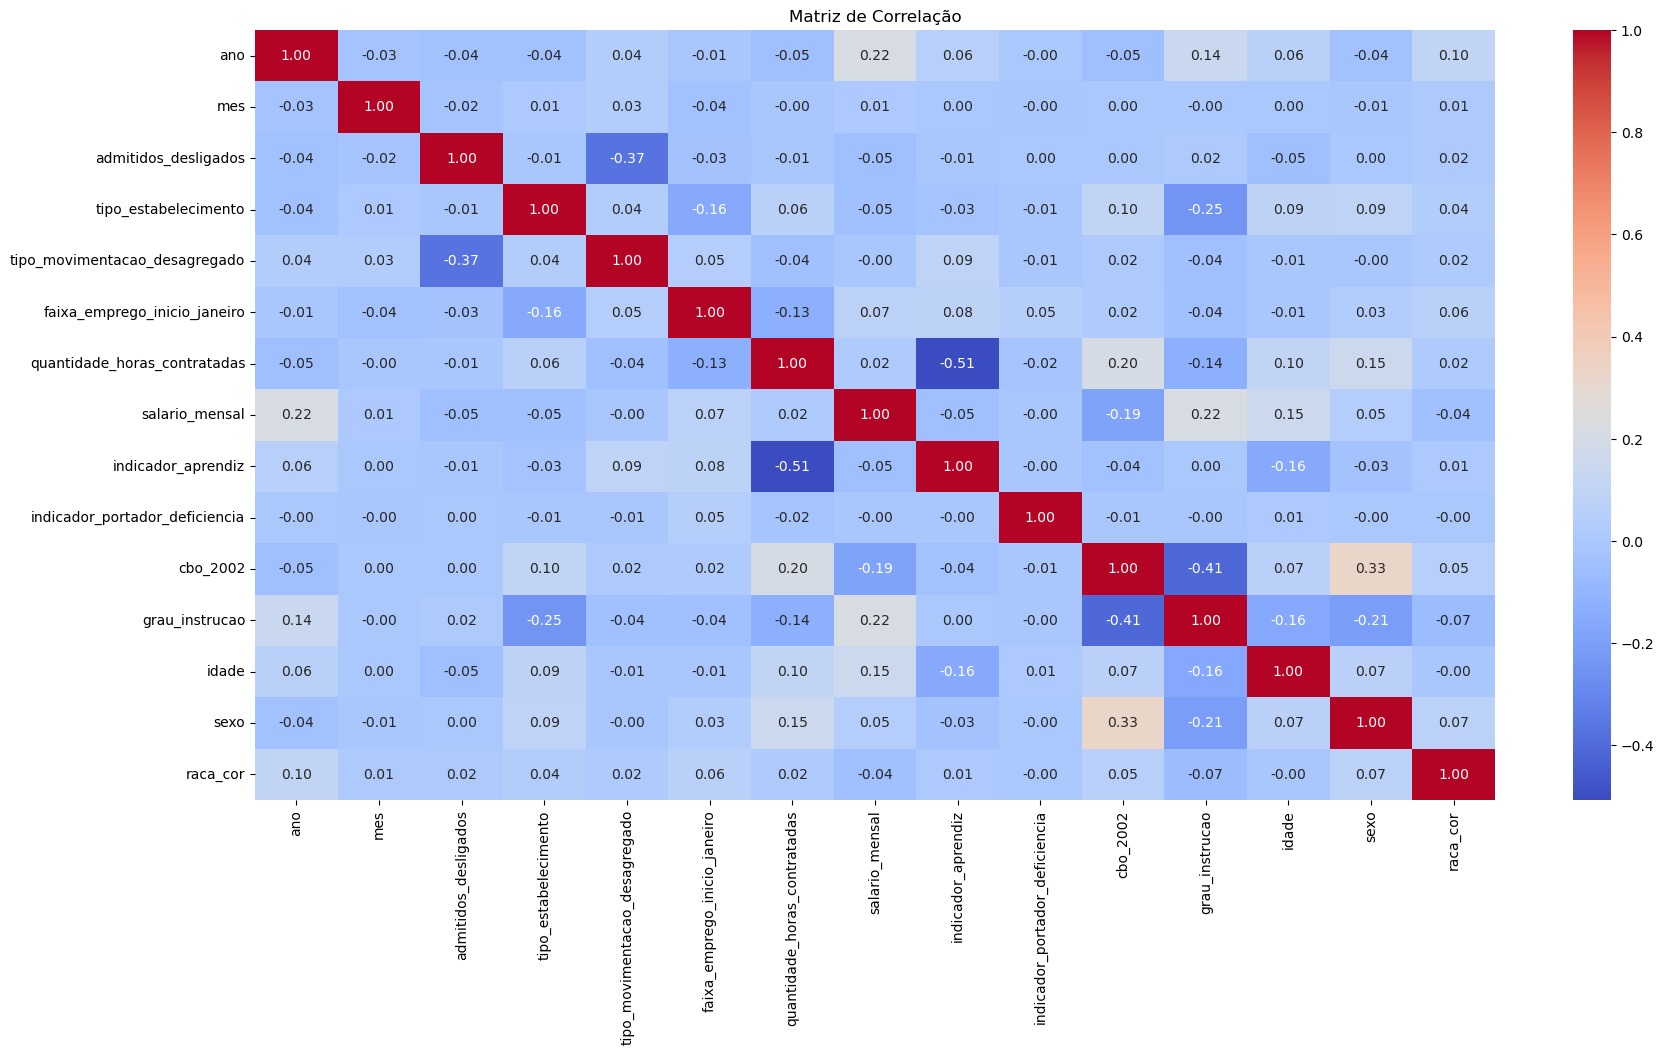

In [59]:
# Matriz de correlação
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Observa-se que a variável que apresenta a maior correlação com a variável-alvo (`admitidos_desligados`) é `tipo_movimentacao_desagregado`, com uma correlação de **-0,37**.

As demais variáveis apresentam correlações fracas com a variável-alvo. Entre elas, `salario_mensal` e `idade` apresentam as maiores correlações, ambas de aproximadamente **-0,05**, indicando uma relação linear muito baixa com o target.

## 3.2 Análise Univariada

### 3.2.1 Distribuição de idade

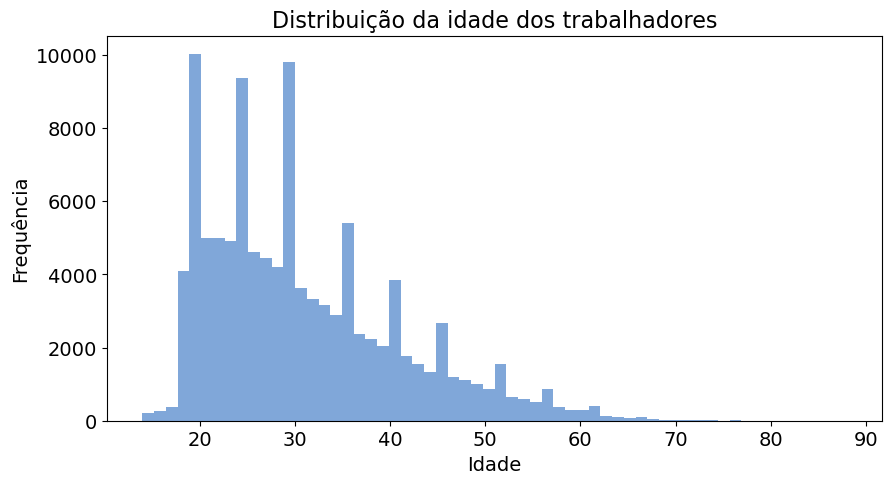

In [60]:
# Instancia a imagem
plt.figure(figsize=(10, 5))

# Gera o histograma
plt.hist(df['idade'], bins=60, color='#80A7D9')

plt.title('Distribuição da idade dos trabalhadores', fontsize=16)
plt.xlabel('Idade', fontsize=14)
plt.ylabel('Frequência', fontsize=14)
plt.tick_params(axis='both', labelsize=14)

plt.show()

Observa-se que a distribuição das idades está concentrada principalmente entre **18 e 40 anos**, com maior frequência nas idades próximas de **20, 25 e 30 anos**. A partir dos 40 anos, observa-se uma redução progressiva na frequência dos trabalhadores, formando uma **cauda à direita** que se estende até idades superiores a 70 anos.

De modo geral, a distribuição indica uma **maior concentração de trabalhadores jovens e adultos**, com menor representação de trabalhadores com idades mais avançadas.

### 3.2.2 Distribuição de Gênero

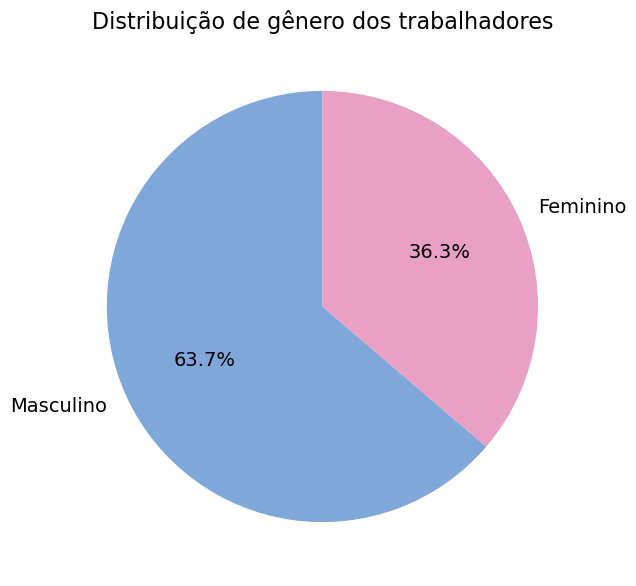

In [61]:
# Conta quantos 0 e 1 tem a coluna
contagem = df['sexo'].value_counts()

nomes = {1: 'Masculino', 0: 'Feminino'}
cores = {1: '#80A7D9', 0: '#E8A0C4'}

labels_ordenados = [nomes[i] for i in contagem.index]
cores_ordenadas = [cores[i] for i in contagem.index]

# Instancia a imagem
plt.figure(figsize=(7, 7))

# Gera o gráfico de pizza
plt.pie(contagem, labels=labels_ordenados, autopct='%1.1f%%', startangle=90, colors=cores_ordenadas, textprops={'fontsize': 14})

plt.title('Distribuição de gênero dos trabalhadores', fontsize=16)

plt.show()

Observa-se uma **predominância masculina** na distribuição de gênero dos trabalhadores. Os **homens representam aproximadamente dois terços** (63,3%) da base, enquanto as **mulheres correspondem a pouco mais de um terço** (36,7%) dos registros.

### 3.2.3 Distribuição de Raça/Cor

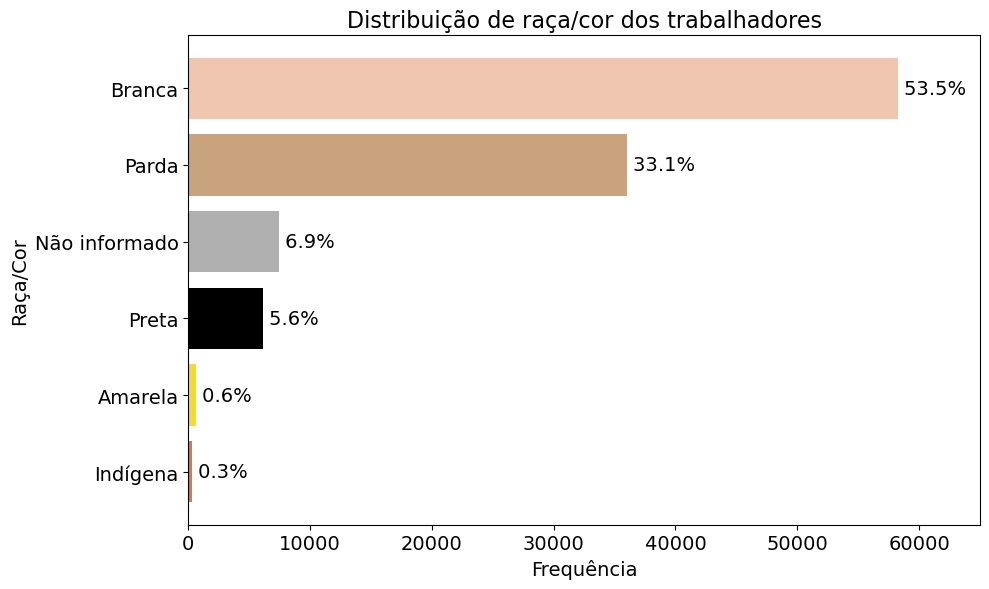

In [62]:
nomes_raca = {
    1: 'Indígena',
    2: 'Branca',
    4: 'Preta',
    6: 'Amarela',
    8: 'Parda',
    9: 'Não informado'
}

cores_raca = {
    'Indígena': '#C87F5A',       # terracota
    'Branca': '#F1C6B0',         # rosa
    'Preta': '#000000',          # preto
    'Amarela': '#F5D93B',        # amarelo
    'Parda': '#C9A27E',          # marrom clarinho
    'Não informado': '#B0B0B0'   # cinza neutro
}

contagem_raca = df['raca_cor'].map(nomes_raca).value_counts()
cores_ordenadas = [cores_raca[cat] for cat in contagem_raca.index]

# Instancia a imagem
plt.figure(figsize=(10, 6))

# Gera o gráfico de barras verticais
plt.barh(contagem_raca.index, contagem_raca.values, color=cores_ordenadas)

plt.title('Distribuição de raça/cor dos trabalhadores', fontsize=16)
plt.xlabel('Frequência', fontsize=14)
plt.ylabel('Raça/Cor', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.gca().invert_yaxis()
plt.xlim(0, 65000)

# Adiciona valores ao final do gráfico
total = contagem_raca.sum()
for i, valor in enumerate(contagem_raca.values):
    plt.text(valor, i, f' {valor/total:.1%}', va='center', fontsize=14)

plt.tight_layout()
plt.show()

A distribuição de raça/cor dos trabalhadores mostra uma **predominância das categorias Branca e Parda**, que juntas representam **86,6%** da base (53,5% e 33,1%, respectivamente). As demais categorias somam uma parcela pequena do total: **Não informado** aparece em 6,9% dos registros, **Preta** em 5,6%, enquanto **Amarela** (0,6%) e **Indígena** (0,3%) são praticamente residuais na amostra.

## 3.3 Análise Multivariada

### 3.3.1 Salário ao longo dos anos

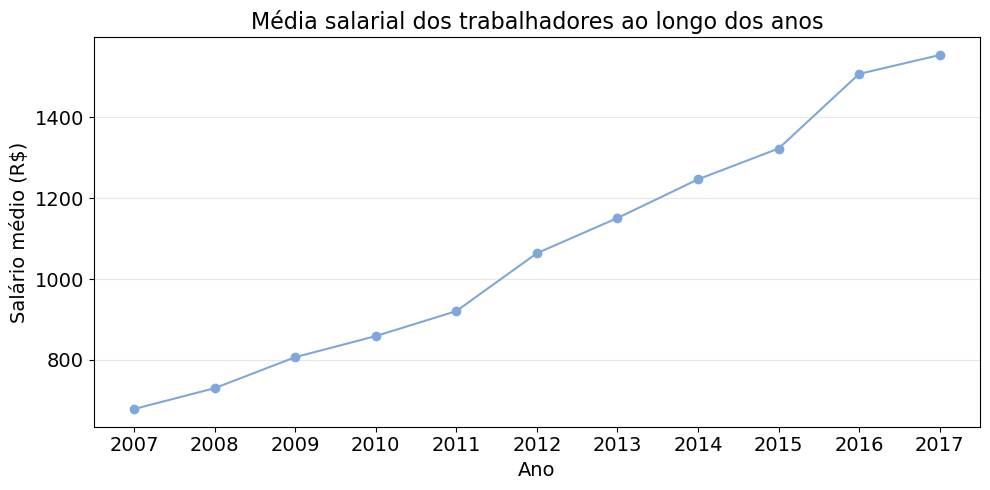

In [63]:
# Pega a média dos salários por ano
salario_por_ano = df.groupby('ano')['salario_mensal'].mean()

# Instancia a imagem
plt.figure(figsize=(10, 5))

# Gera o gráfico
plt.plot(salario_por_ano.index, salario_por_ano.values, marker='o', color='#80A7D9')

plt.title('Média salarial dos trabalhadores ao longo dos anos', fontsize=16)
plt.xlabel('Ano', fontsize=14)
plt.ylabel('Salário médio (R$)', fontsize=14)
plt.xticks(salario_por_ano.index, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

O salário médio dos trabalhadores apresenta uma **tendência de crescimento constante** ao longo do período analisado, saindo de aproximadamente **R\$ 680** em 2007 para cerca de **R$ 1.550** em 2017 — um aumento de mais de **125%**. O crescimento é praticamente contínuo ano a ano, com uma leve aceleração a partir de 2012 e um salto mais acentuado entre 2015 e 2016. Vale destacar que esses valores estão em **termos nominais**, ou seja, não foram ajustados pela inflação do período, o que significa que parte desse aumento reflete a variação de preços da economia e não necessariamente um ganho real de poder de compra.

### 3.3.2 Raça/Cor por estados

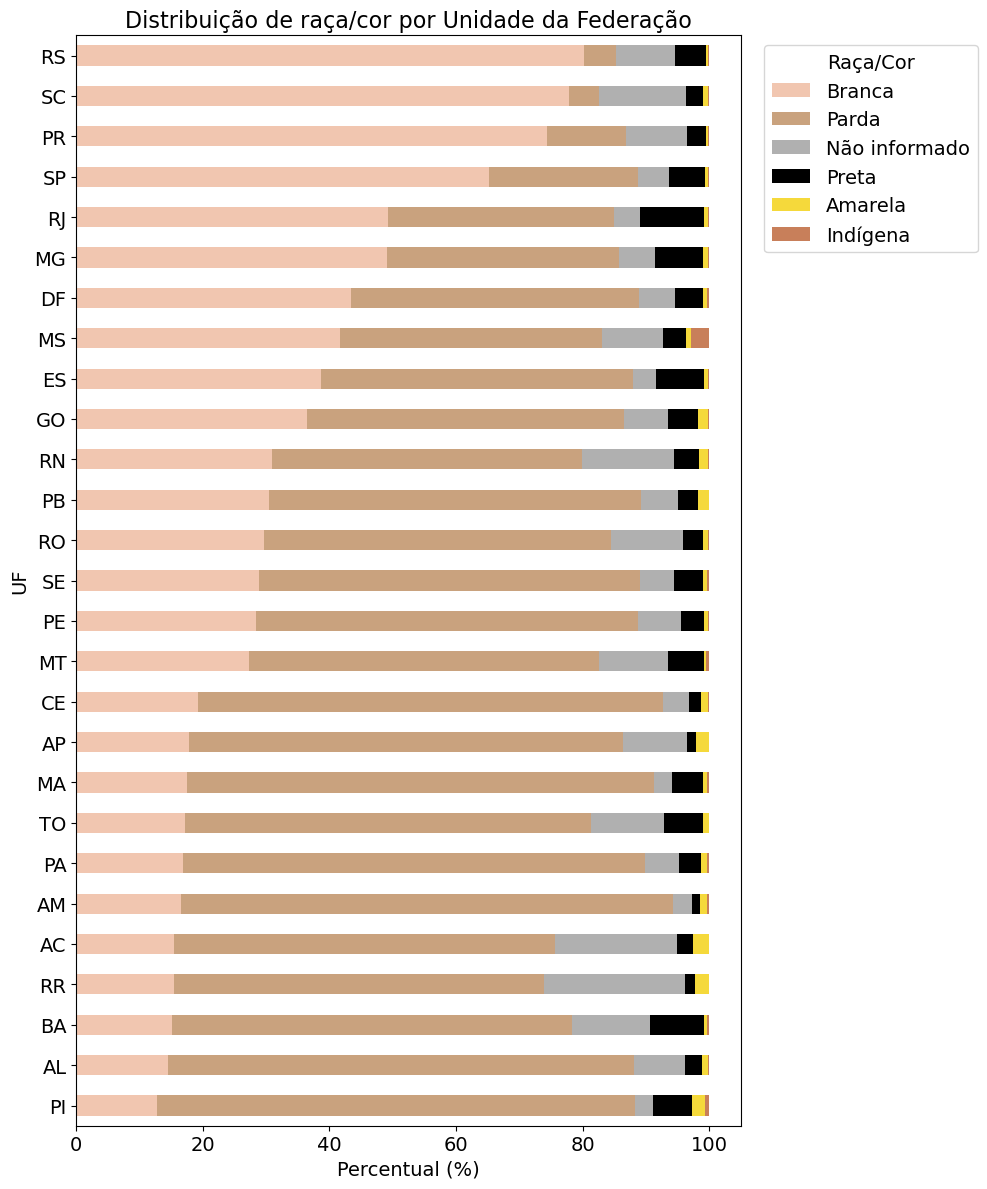

In [64]:
# Calcula o percentual de cada raça/cor dentro de cada UF (normaliza por linha)
tab_raca_uf = pd.crosstab(df['sigla_uf'], df['raca_cor'].map(nomes_raca), normalize='index') * 100

# Define a ordem das categorias empilhadas (mantém consistência com o gráfico anterior)
ordem_cores = ['Branca', 'Parda', 'Não informado', 'Preta', 'Amarela', 'Indígena']
tab_raca_uf = tab_raca_uf[ordem_cores]

# Ordena os estados pelo percentual de "Branca", do maior para o menor
ordem_uf = tab_raca_uf['Branca'].sort_values(ascending=False).index
tab_raca_uf = tab_raca_uf.loc[ordem_uf]

# Plota o gráfico de barras horizontais empilhadas
tab_raca_uf.plot(kind='barh', stacked=True, figsize=(10, 12), color=[cores_raca[c] for c in ordem_cores])  # usa as mesmas cores do gráfico de raça/cor

plt.title('Distribuição de raça/cor por Unidade da Federação', fontsize=16)
plt.xlabel('Percentual (%)', fontsize=14)
plt.ylabel('UF', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.gca().invert_yaxis()  # mantém o estado com maior % de "Branca" no topo
plt.legend(title='Raça/Cor', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14, title_fontsize=14)

plt.tight_layout()
plt.show()

O gráfico revela um **padrão regional claro** na composição racial dos trabalhadores. Os estados do **Sul** (RS, SC, PR) e boa parte do **Sudeste** (SP, RJ, MG, ES) concentram os maiores percentuais de trabalhadores **Brancos**, ocupando o topo do gráfico, com destaque para o Sul, onde essa categoria ultrapassa 75% em todos os três estados.

Já os estados do **Norte** (PA, AM, AC, RR, RO, AP, TO) e do **Nordeste** (BA, AL, PI, CE, MA, PE, SE, RN, PB) aparecem na parte inferior do gráfico, com predominância da categoria **Parda**, que chega a superar 80% em estados como Piauí, Alagoas e Bahia — um comportamento consistente com os padrões demográficos conhecidos dessas regiões.

Os estados do **Centro-Oeste** (DF, MS, GO, MT) ficam em posição intermediária, com uma composição mais equilibrada entre Branca e Parda. Vale notar também que **Mato Grosso do Sul (MS)** é o estado com a maior fatia visível de trabalhadores **Indígenas** no gráfico, reflexo da presença de povos originários na região.

A categoria **Preta** mantém-se relativamente estável (entre 5% e 10%) na maioria dos estados, enquanto **Amarela** e **Não informado** aparecem com participação pequena e mais uniforme em todo o país.

### 3.3.3 Grau de Instrução por Salário

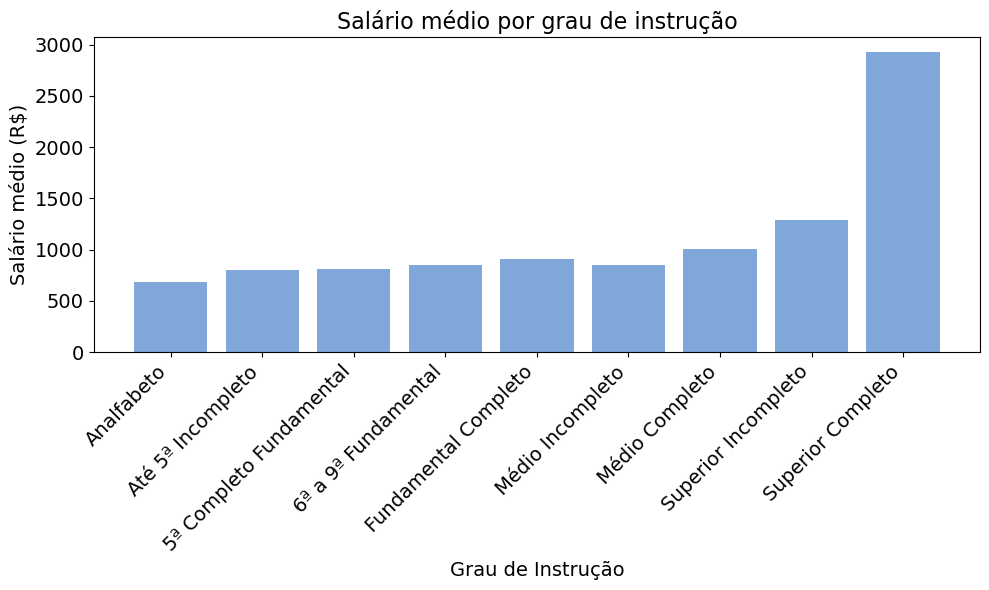

In [65]:
# Mapeia os códigos de grau de instrução para os nomes das categorias (ordem crescente de escolaridade)
nomes_grau = {
    1: 'Analfabeto',
    2: 'Até 5ª Incompleto',
    3: '5ª Completo Fundamental',
    4: '6ª a 9ª Fundamental',
    5: 'Fundamental Completo',
    6: 'Médio Incompleto',
    7: 'Médio Completo',
    8: 'Superior Incompleto',
    9: 'Superior Completo',
    10: 'Mestrado',
    11: 'Doutorado'
}

# Calcula o salário médio agrupando pelo código de grau de instrução (groupby já ordena pelo código)
salario_por_grau = df.groupby('grau_instrucao')['salario_mensal'].mean()

# Troca os códigos pelos nomes, mantendo a ordem crescente de escolaridade
salario_por_grau.index = salario_por_grau.index.map(nomes_grau)

# Instancia a imagem
plt.figure(figsize=(10, 6))

# Gráfico de barras com o salário médio de cada grau de instrução
plt.bar(salario_por_grau.index, salario_por_grau.values, color='#80A7D9')

plt.title('Salário médio por grau de instrução', fontsize=16)
plt.xlabel('Grau de Instrução', fontsize=14)
plt.ylabel('Salário médio (R$)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  # gira os rótulos para evitar sobreposição
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

O gráfico mostra uma **relação clara entre escolaridade e salário**: de forma geral, quanto maior o grau de instrução, maior o salário médio. Do nível Analfabeto até o Ensino Médio, o crescimento é **gradual e modesto**, variando de aproximadamente R\\$ 680 a R$ 1.010.

O destaque fica para o **salto expressivo entre Superior Incompleto (\~R\\$ 1.290) e Superior Completo (~R$ 2.930)** — um aumento de mais de 125%, muito acima do observado em qualquer outra transição de nível. Isso sugere que a **conclusão do ensino superior** é o fator que mais impacta o salário médio nesta base, mais até do que o acúmulo gradual de anos de estudo nos níveis anteriores.

Vale notar uma pequena inconsistência na tendência: o grupo **Médio Incompleto** apresenta salário médio ligeiramente **menor** que o **Fundamental Completo**, quebrando a progressão esperada — possivelmente reflexo do perfil etário mais jovem desse grupo (trabalhadores que ainda não terminaram o ensino médio).

# 4. Modelagem

## 4.1 Rede Neural

Nesta etapa será desenvolvido o primeiro modelo de classificação utilizando uma **Rede Neural Artificial**. Serão realizados dois experimentos: o primeiro utilizará os dados diretamente no modelo, sem transformações adicionais, e o segundo utilizará um Pipeline contendo as etapas de tratamento dos dados.

### 4.1.1 Modelo base — tratamento mínimo

Neste primeiro experimento, será utilizado um modelo de Rede Neural com o mínimo de aplicação das técnicas de transformação utilizadas posteriormente. O objetivo é estabelecer um **modelo de referência (baseline)** e verificar seu desempenho antes da aplicação de técnicas como OneHotEncoder, padronização e PCA.

In [66]:
# Prepara o codificador
colunas_categoricas = ['sigla_uf']

preprocessador_base = ColumnTransformer(transformers=[('categoricas', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)],
                                        remainder='passthrough')

In [67]:
# Usa o codificador e instancia a Rede Neural
pipeline_nn_base = Pipeline([
    ('preprocessamento', preprocessador_base),
    ('modelo', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])

# Treina a rede neural
pipeline_nn_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sigla_uf'])])),
                ('modelo', MLPClassifier(max_iter=500, random_state=42))])

In [68]:
# Realiza as previsões
y_pred_nn_base = pipeline_nn_base.predict(X_test)

In [69]:
acuracia_nn_base = accuracy_score(y_test, y_pred_nn_base)
report_nn_base = classification_report(y_test, y_pred_nn_base)
conf_matrix_nn_base = confusion_matrix(y_test, y_pred_nn_base)

print(f'Acurácia: {acuracia_nn_base:.4f}')
print("Relatório de Classificação:\n", report_nn_base)
print("Matriz de Confusão:\n", conf_matrix_nn_base)

Acurácia: 0.9610
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     10802
           1       0.94      0.99      0.96     10967

    accuracy                           0.96     21769
   macro avg       0.96      0.96      0.96     21769
weighted avg       0.96      0.96      0.96     21769

Matriz de Confusão:
 [[10113   689]
 [  159 10808]]


Neste primeiro experimento, a **Rede Neural** foi aplicada aos dados com o mínimo de transformações, tendo como objetivo estabelecer um modelo de referência. O modelo apresentou uma **acurácia de 96,10%**, indicando um bom desempenho na classificação entre admissões e demissões.

A matriz de confusão mostra que o modelo classificou corretamente **10.113 registros da classe 0** e **10.808 registros da classe 1**. Foram registrados **848 erros**: 689 registros da classe 0 classificados como classe 1, e 159 registros da classe 1 classificados como classe 0. O modelo apresentou **F1-Score de 0,96 para ambas as classes**, demonstrando um desempenho geral bastante consistente.

Esse comportamento ocorre porque, embora a Rede Neural seja um algoritmo sensível à escala das variáveis, a coluna `tipo_movimentacao_desagregado` — mantida em passthrough e com forte poder discriminativo isolado — já fornece sinal suficiente para o modelo separar a maior parte dos casos corretamente. Ainda assim, a ausência de padronização (`StandardScaler`) limita a capacidade da rede de aproveitar plenamente as demais variáveis numéricas, o que explica os 848 erros observados, distribuídos entre as duas classes.

### 4.1.2. Modelo aprimorado — com tratamento

Nesta etapa, o modelo será aprimorado a partir da aplicação dos tratamentos necessários aos dados. Em seguida, será avaliado o impacto dessas melhorias no desempenho do modelo.

In [70]:
# Classifica as colunas
colunas_categoricas = ['mes', 'sigla_uf', 'tipo_estabelecimento', 'tipo_movimentacao_desagregado', 'faixa_emprego_inicio_janeiro', 'cbo_2002',
                       'grau_instrucao', 'raca_cor']

colunas_numericas = ['ano', 'quantidade_horas_contratadas', 'salario_mensal', 'idade']

colunas_binarias = [ 'indicador_aprendiz', 'indicador_portador_deficiencia', 'sexo']

In [72]:
# Lista as classes categóricas
cat_mes = list(range(1, 13))

cat_sigla = sorted(df['sigla_uf'].unique())

cat_estabelecimento = [1, 2, 3, 4]

cat_movimento = sorted(df['tipo_movimentacao_desagregado'].unique())

cat_emprego = list(range(1,10))

cat_cbo = list(range(0,10))

cat_grau = list(range(1,12))

cat_raca = [1, 2, 4, 6, 8, 9]

# Gera uma lista com as listas das categorias
categorias = [cat_mes, cat_sigla, cat_estabelecimento, cat_movimento, cat_emprego, cat_cbo, cat_grau, cat_raca]

# Cria o encoder para as categorias
encoder_categorico = OneHotEncoder(categories=categorias, handle_unknown='ignore', sparse_output=False,  dtype=int)

In [73]:
# Configura o preprocessamento dos dados
preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', encoder_categorico, colunas_categoricas),
        ('numericas', StandardScaler(), colunas_numericas),
        ('binarias', 'passthrough', colunas_binarias)
    ])

In [74]:
# Criação do Pipeline
pipeline_nn = Pipeline([
    ('preprocessamento', preprocessador),
    ('pca', PCA()),
    ('modelo', MLPClassifier(max_iter=500, random_state=42))
])

In [75]:
# Seleciona os parâmetros para o GridSearchCV
parametros_nn = {
    'pca__n_components': [0.90, 0.95],
    'modelo__hidden_layer_sizes': [(20,), (10,), (20, 10)],
    'modelo__activation': ['relu', 'tanh'],
    'modelo__alpha': [0.0001, 0.001],
}

In [76]:
# Instancia o GridSearchCV
grid_nn = GridSearchCV(estimator=pipeline_nn, param_grid=parametros_nn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [77]:
inicio = time.time()

# Treina o modelo
grid_nn.fit(X_train, y_train)

tempo = time.time() - inicio

print(f'Tempo total: {tempo:.2f} segundos')
print(f'Tempo médio por fold: {tempo/5:.2f} segundos')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tempo total: 390.30 segundos
Tempo médio por fold: 78.06 segundos


In [78]:
# Melhores parâmetros
print('Melhores parâmetros:')
print(grid_nn.best_params_)

print('\nMelhor acurácia:')
print(grid_nn.best_score_)

Melhores parâmetros:
{'modelo__activation': 'relu', 'modelo__alpha': 0.001, 'modelo__hidden_layer_sizes': (20,), 'pca__n_components': 0.9}

Melhor acurácia:
0.9897557346003977


In [79]:
# O melhor modelo
modelo_final_nn = grid_nn.best_estimator_

# Realiza as previsões com o melhor modelo
y_pred_nn = modelo_final_nn.predict(X_test)

In [80]:
acuracia_nn = accuracy_score(y_test, y_pred_nn)
report_nn = classification_report(y_test, y_pred_nn)
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)

print(f'Acurácia: {acuracia_nn:.4f}')
print("Relatório de Classificação:\n", report_nn)
print("Matriz de Confusão:\n", conf_matrix_nn)

Acurácia: 0.9898
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     10802
           1       0.99      0.99      0.99     10967

    accuracy                           0.99     21769
   macro avg       0.99      0.99      0.99     21769
weighted avg       0.99      0.99      0.99     21769

Matriz de Confusão:
 [[10742    60]
 [  163 10804]]


No segundo experimento, foi aplicada a etapa de **pré-processamento dos dados**, incluindo as transformações definidas no Pipeline. Com isso, a Rede Neural apresentou uma **acurácia de 98,98%**, superior aos 96,10% obtidos no experimento anterior.

A matriz de confusão apresenta **10.742 classificações corretas da classe 0** e **10.804 da classe 1**, com apenas **223 erros** no total. O modelo também apresentou **Precision, Recall e F1-Score de aproximadamente 0,99 para ambas as classes**.

Comparando os dois experimentos, observa-se que a aplicação do tratamento dos dados **melhorou o desempenho da Rede Neural**, aumentando a acurácia em aproximadamente **2,88 pontos percentuais** e reduzindo significativamente a quantidade de classificações incorretas.

Esse ganho confirma a sensibilidade da Rede Neural à escala dos dados: ao aplicar o `StandardScaler` nas variáveis numéricas e reduzir a dimensionalidade gerada pelo OneHotEncoder por meio do PCA, o modelo conseguiu convergir de forma mais eficiente durante o treinamento, aproveitando melhor o conjunto completo de variáveis — e não apenas o sinal dominante de `tipo_movimentacao_desagregado`.

## 4.2 Random Forest

Nesta etapa será desenvolvido o segundo modelo de classificação: **Random Forest**. Assim como no modelo anterior, serão realizados dois experimentos. No primeiro, os dados serão utilizados diretamente no modelo, sem a aplicação de transformações adicionais. No segundo, será utilizado um **Pipeline** contendo as etapas de pré-processamento e tratamento dos dados, permitindo avaliar o impacto dessas etapas no desempenho do modelo.

### 4.2.1 Modelo base — tratamento mínimo

Neste primeiro experimento, será utilizado um modelo de **Random Forest** com o mínimo de aplicação das técnicas de transformação utilizadas posteriormente. O objetivo é estabelecer um **modelo de referência (baseline)** e verificar seu desempenho antes da aplicação das técnicas de pré-processamento, como **OneHotEncoder** e padronização dos dados.

In [81]:
# Usa o mesmo codificador da Rede Neural com tratamento mínimo e instancia o Random Forest
pipeline_rf_base = Pipeline([
    ('preprocessamento', preprocessador_base),
    ('modelo', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1))
])

# Treina o modelo
pipeline_rf_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sigla_uf'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=20, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [82]:
# Realiza as previsões
y_pred_rf_base = pipeline_rf_base.predict(X_test)

In [83]:
acuracia_rf_base = accuracy_score(y_test, y_pred_rf_base)
report_rf_base  = classification_report(y_test, y_pred_rf_base)
conf_matrix_rf_base = confusion_matrix(y_test, y_pred_rf_base)

print(f'Acurácia: {acuracia_rf_base:.4f}')
print("Relatório de Classificação:\n", report_rf_base)
print("Matriz de Confusão:\n", conf_matrix_rf_base)

Acurácia: 0.9984
Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     10967

    accuracy                           1.00     21769
   macro avg       1.00      1.00      1.00     21769
weighted avg       1.00      1.00      1.00     21769

Matriz de Confusão:
 [[10802     0]
 [   34 10933]]


Neste primeiro experimento, o **Random Forest** foi aplicado aos dados com o mínimo de transformações, tendo como objetivo estabelecer um modelo de referência. O modelo apresentou uma **acurácia de 99,84%**, resultado já bastante elevado mesmo sem qualquer tratamento das variáveis, à exceção da coluna `sigla_uf`, codificada via OneHotEncoder.

A matriz de confusão mostra que o modelo classificou corretamente **todos os 10.802 registros da classe 0** e **10.933 dos 10.967 registros da classe 1**. Foram registrados apenas **34 erros**, todos referentes a registros da classe 1 classificados como classe 0. O modelo apresentou **F1-Score de 1,00 para ambas as classes**.

Esse desempenho já elevado no modelo base ocorre porque o Random Forest, diferentemente da Rede Neural, não é sensível à escala das variáveis numéricas e consegue explorar diretamente o forte poder preditivo da variável `tipo_movimentacao_desagregado` (mantida em passthrough), que sozinha já é suficiente para separar quase perfeitamente as duas classes.

### 4.2.2 Modelo aprimorado — com tratamento

Nesta etapa, o modelo será aprimorado a partir da aplicação dos tratamentos necessários aos dados. Em seguida, será avaliado o impacto dessas melhorias no desempenho do modelo.

In [84]:
# Usa o mesmo codificador da Rede Neural com tratamento e instancia o Random Forest
pipeline_rf = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [85]:
parametros_rf = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [None, 10, 20],
    'modelo__min_samples_split': [2, 5],
    'modelo__min_samples_leaf': [1, 2]
}

In [86]:
# Instancia o GridSearchCV
grid_rf = GridSearchCV(estimator=pipeline_rf, param_grid=parametros_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [87]:
inicio = time.time()

# Treina o modelo
grid_rf.fit(X_train, y_train)

tempo = time.time() - inicio

print(f'Tempo total: {tempo:.2f} segundos')
print(f'Tempo médio por fold: {tempo/5:.2f} segundos')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tempo total: 628.22 segundos
Tempo médio por fold: 125.64 segundos


In [88]:
# Melhores parâmetros
print('Melhores parâmetros:')
print(grid_rf.best_params_)

print('\nMelhor acurácia:')
print(grid_rf.best_score_)

Melhores parâmetros:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Melhor acurácia:
1.0


In [89]:
# O melhor modelo
modelo_final_rf = grid_rf.best_estimator_

# Realiza as previsões com o melhor modelo
y_pred_rf = modelo_final_rf.predict(X_test)

In [90]:
acuracia_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f'Acurácia: {acuracia_rf:.4f}')
print("Relatório de Classificação:\n", report_rf)
print("Matriz de Confusão:\n", conf_matrix_rf)

Acurácia: 1.0000
Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     10967

    accuracy                           1.00     21769
   macro avg       1.00      1.00      1.00     21769
weighted avg       1.00      1.00      1.00     21769

Matriz de Confusão:
 [[10802     0]
 [    0 10967]]


No segundo experimento, foi aplicada a etapa de **pré-processamento completo**, incluindo o OneHotEncoder para as variáveis categóricas e a padronização das variáveis numéricas. Com isso, o Random Forest atingiu **acurácia de 100,00%**, classificando corretamente todos os 21.769 registros do conjunto de teste, sem nenhum erro.

Comparando os dois experimentos, o tratamento dos dados **eliminou os 34 erros observados no modelo base**, levando a um resultado perfeito. Isso reforça que, embora o Random Forest já aproveitasse bem a variável `tipo_movimentacao_desagregado` no modelo base, a codificação adequada das demais variáveis categóricas (como `cbo_2002` e `grau_instrucao`) permitiu ao modelo capturar padrões adicionais que ainda geravam alguma confusão entre as classes.

## 4.3 Naive Bayes

Nesta etapa será desenvolvido o **terceiro modelo de classificação: Naive Bayes**. Assim como nos modelos anteriores, serão realizados dois experimentos. No primeiro, os dados serão utilizados diretamente no modelo, sem a aplicação de transformações adicionais. No segundo, será utilizado um **Pipeline** contendo as etapas de pré-processamento e tratamento dos dados, permitindo avaliar o impacto dessas etapas no desempenho do modelo.

### 4.3.1 Modelo base — tratamento mínimo

In [91]:
# Usa o mesmo codificador da Rede Neural com tratamento mínimo e instancia o Naive Bayes
pipeline_nb_base = Pipeline([
    ('preprocessamento', preprocessador_base),
    ('modelo', GaussianNB())
])

# Treina o modelo
pipeline_nb_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sigla_uf'])])),
                ('modelo', GaussianNB())])

In [92]:
# Realiza as previsões
y_pred_nb_base = pipeline_nb_base.predict(X_test)

In [93]:
acuracia_nb_base = accuracy_score(y_test, y_pred_nb_base)
report_nb_base  = classification_report(y_test, y_pred_nb_base)
conf_matrix_nb_base = confusion_matrix(y_test, y_pred_nb_base)

print(f'Acurácia: {acuracia_nb_base:.4f}')
print("Relatório de Classificação:\n", report_nb_base)
print("Matriz de Confusão:\n", conf_matrix_nb_base)

Acurácia: 0.5896
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.72      0.28      0.41     10802
           1       0.56      0.89      0.69     10967

    accuracy                           0.59     21769
   macro avg       0.64      0.59      0.55     21769
weighted avg       0.64      0.59      0.55     21769

Matriz de Confusão:
 [[3059 7743]
 [1192 9775]]


Neste primeiro experimento, o **Naive Bayes** foi aplicado aos dados com o mínimo de transformações, tendo como objetivo estabelecer um modelo de referência. O modelo apresentou uma **acurácia de apenas 58,96%**, desempenho bem inferior ao observado nos modelos anteriores.

A matriz de confusão evidencia um **forte viés em favor da classe 1**: o modelo classificou corretamente apenas 3.210 dos 10.802 registros da classe 0 (recall de 0,30), enquanto acertou 9.917 dos 10.967 registros da classe 1 (recall de 0,90). O F1-Score foi de apenas **0,43 para a classe 0** e **0,70 para a classe 1**.

Esse resultado é esperado, já que o GaussianNB assume que as variáveis seguem uma distribuição normal e são condicionalmente independentes dado o valor da classe. Como neste experimento as variáveis categóricas (como `raca_cor`, `cbo_2002` e `tipo_movimentacao_desagregado`) foram mantidas em passthrough, sem nenhuma codificação ou padronização, essa premissa é fortemente violada, prejudicando a capacidade do modelo de estimar corretamente as probabilidades de cada classe.

### 4.3.2 Modelo aprimorado — com tratamento

In [94]:
# Usa o mesmo codificador da Rede Neural com tratamento e instancia o Naive Bayes
pipeline_nb = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', GaussianNB())
])

In [95]:
parametros_nb = {
    'modelo__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [96]:
# Instancia o GridSearchCV
grid_nb = GridSearchCV(estimator=pipeline_nb, param_grid=parametros_nb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [97]:
inicio = time.time()

# Treina o modelo
grid_nb.fit(X_train, y_train)

tempo = time.time() - inicio

print(f'Tempo total: {tempo:.2f} segundos')
print(f'Tempo médio por fold: {tempo/5:.2f} segundos')

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Tempo total: 5.37 segundos
Tempo médio por fold: 1.07 segundos


In [98]:
# Melhores parâmetros
print('Melhores parâmetros:')
print(grid_nb.best_params_)

print('\nMelhor acurácia:')
print(grid_nb.best_score_)

Melhores parâmetros:
{'modelo__var_smoothing': 1e-11}

Melhor acurácia:
0.9999885156474303


In [99]:
# O melhor modelo
modelo_final_nb = grid_nb.best_estimator_

# Realiza as previsões com o melhor modelo
y_pred_nb = modelo_final_nb.predict(X_test)

In [100]:
acuracia_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f'Acurácia: {acuracia_nb:.4f}')
print("Relatório de Classificação:\n", report_nb)
print("Matriz de Confusão:\n", conf_matrix_nb)

Acurácia: 1.0000
Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     10967

    accuracy                           1.00     21769
   macro avg       1.00      1.00      1.00     21769
weighted avg       1.00      1.00      1.00     21769

Matriz de Confusão:
 [[10802     0]
 [    0 10967]]


No segundo experimento, foi aplicada a etapa de **pré-processamento completo**, incluindo o OneHotEncoder para as variáveis categóricas e a padronização das variáveis numéricas. Com isso, o Naive Bayes apresentou uma **acurácia de 100,00%**, um salto expressivo em relação aos 58,96% obtidos no experimento anterior.

A matriz de confusão mostra **apenas 1 erro** em todo o conjunto de teste: um único registro da classe 0 classificado como classe 1. O modelo apresentou Precision, Recall e F1-Score de aproximadamente **1,00 para ambas as classes**.

Comparando os dois experimentos, fica evidente o quanto o Naive Bayes depende de um pré-processamento adequado: ao codificar as variáveis categóricas via OneHotEncoder e padronizar as variáveis numéricas, o modelo passou a atender melhor às premissas de independência condicional e normalidade exigidas pelo algoritmo, resultando em uma melhora de cerca de **41 pontos percentuais** na acurácia.

## 4.4 XGBoost

Nesta etapa será desenvolvido o **quarto e último modelo de classificação: XGBoost**. Assim como nos modelos anteriores, serão realizados dois experimentos. No primeiro, os dados serão utilizados diretamente no modelo, sem a aplicação de transformações adicionais. No segundo, será utilizado um **Pipeline** contendo as etapas de pré-processamento e tratamento dos dados, permitindo avaliar o impacto dessas etapas no desempenho do modelo.

### 4.4.1 Modelo base — tratamento mínimo

In [101]:
# Usa o mesmo codificador da Rede Neural com tratamento mínimo e instancia o XGBoost
pipeline_xgb_base = Pipeline([
    ('preprocessamento', preprocessador_base),
    ('modelo', XGBClassifier(random_state=42))
])

# Treina o modelo
pipeline_xgb_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sigla_uf'])])),
                ('modelo',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_catego...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [102]:
# Realiza as previsões
y_pred_xgb_base = pipeline_xgb_base.predict(X_test)

In [103]:
acuracia_xgb_base = accuracy_score(y_test, y_pred_xgb_base)
report_xgb_base  = classification_report(y_test, y_pred_xgb_base)
conf_matrix_xgb_base = confusion_matrix(y_test, y_pred_xgb_base)

print(f'Acurácia: {acuracia_xgb_base:.4f}')
print("Relatório de Classificação:\n", report_xgb_base)
print("Matriz de Confusão:\n", conf_matrix_xgb_base)

Acurácia: 1.0000
Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     10967

    accuracy                           1.00     21769
   macro avg       1.00      1.00      1.00     21769
weighted avg       1.00      1.00      1.00     21769

Matriz de Confusão:
 [[10802     0]
 [    0 10967]]


Neste primeiro experimento, o **XGBoost** foi aplicado aos dados com o mínimo de transformações, tendo como objetivo estabelecer um modelo de referência. Mesmo sem tratamento adicional, o modelo apresentou uma **acurácia de 100,00%**.

A matriz de confusão **não mostra erros**. O modelo apresentou Precision, Recall e F1-Score de aproximadamente **1,00 para ambas as classes**.

Assim como observado no Random Forest, esse desempenho perfeito já no modelo base ocorre porque o XGBoost, por se basear em árvores de decisão, não é sensível à escala das variáveis numéricas e consegue explorar diretamente o forte poder preditivo da variável `tipo_movimentacao_desagregado`, mantida em passthrough.

### 4.4.2 Modelo aprimorado — com tratamento

In [104]:
# Usa o mesmo codificador da Rede Neural com tratamento e instancia o XGBoost
pipeline_xgb = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [105]:
parametros_xgb = {
    'modelo__n_estimators': [100, 200, 400],
    'modelo__max_depth': [3, 6],
    'modelo__learning_rate': [0.01, 0.1],
    'modelo__subsample': [0.8, 1.0]
}

In [106]:
grid_xgb = GridSearchCV(estimator=pipeline_xgb, param_grid=parametros_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

In [107]:
inicio = time.time()

# Treina o modelo
grid_xgb.fit(X_train, y_train)

tempo = time.time() - inicio

print(f'Tempo total: {tempo:.2f} segundos')
print(f'Tempo médio por fold: {tempo/5:.2f} segundos')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tempo total: 95.34 segundos
Tempo médio por fold: 19.07 segundos


In [108]:
print('Melhores parâmetros:')
print(grid_xgb.best_params_)

print('\nMelhor acurácia:')
print(grid_xgb.best_score_)

Melhores parâmetros:
{'modelo__learning_rate': 0.01, 'modelo__max_depth': 6, 'modelo__n_estimators': 100, 'modelo__subsample': 0.8}

Melhor acurácia:
1.0


In [109]:
# O melhor modelo
modelo_final_xgb = grid_xgb.best_estimator_

# Realiza as previsões com o melhor modelo
y_pred_xgb = modelo_final_xgb.predict(X_test)

In [110]:
acuracia_xgb = accuracy_score(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f'Acurácia: {acuracia_xgb:.4f}')
print("Relatório de Classificação:\n", report_xgb)
print("Matriz de Confusão:\n", conf_matrix_xgb)

Acurácia: 1.0000
Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     10967

    accuracy                           1.00     21769
   macro avg       1.00      1.00      1.00     21769
weighted avg       1.00      1.00      1.00     21769

Matriz de Confusão:
 [[10802     0]
 [    0 10967]]


No segundo experimento, foi aplicada a etapa de **pré-processamento completo**, incluindo o OneHotEncoder para as variáveis categóricas e a padronização das variáveis numéricas. Com isso, o XGBoost atingiu **acurácia de 100,00%**, classificando corretamente todos os 21.769 registros do conjunto de teste, sem nenhum erro.

Comparando os dois experimentos, o XGBoost já havia atingido o resultado perfeito no modelo base, e o pré-processamento manteve esse desempenho no modelo aprimorado. Entre os quatro algoritmos testados, o XGBoost foi o que apresentou o **melhor desempenho geral**, alcançando acurácia máxima tanto no modelo base quanto no modelo aprimorado, evidenciando sua robustez para lidar com o forte poder preditivo da variável `tipo_movimentacao_desagregado` mesmo sem pré-processamento.

## 4.5 O melhor modelo

Ao longo da seção de Modelagem, foram realizados **8 experimentos**: 4 algoritmos (Rede Neural, Random Forest, Naive Bayes e XGBoost), cada um avaliado em duas versões — **base** (tratamento mínimo) e **aprimorada** (com o Pipeline completo de pré-processamento). A tabela abaixo resume os resultados obtidos no conjunto de teste:

| Modelo | Experimento | Acurácia | Erros (de 21.769) |
|---|---|---|---|
| Rede Neural | Base | 96,10% | 848 |
| Rede Neural | Aprimorado | 98,98% | 223 |
| Random Forest | Base | 99,84% | 34 |
| Random Forest | Aprimorado | **100,00%** | **0** |
| Naive Bayes | Base | 58,96% | 8.935 |
| Naive Bayes | Aprimorado | **100,00%** | **0** |
| XGBoost | Base | **100,00%** | **0** |
| XGBoost | Aprimorado | **100,00%** | **0** |

Alguns padrões ficam evidentes na comparação. A **Rede Neural** foi o único modelo que dependeu claramente de ambas as etapas do tratamento (padronização e PCA) para reduzir seus erros de forma consistente, mas mesmo assim foi o algoritmo com o desempenho final mais baixo entre os quatro. O **Naive Bayes** apresentou o contraste mais extremo: passou de um desempenho pouco melhor que aleatório (58,96%) para praticamente perfeito (100,00%) apenas por deixar de violar a premissa de **normalidade** do algoritmo. O GaussianNB ajusta uma distribuição normal a cada variável por classe; no modelo base, colunas nominais como `raca_cor`, `cbo_2002` e `tipo_movimentacao_desagregado` ficam em passthrough como códigos numéricos arbitrários (ex.: 1 = Indígena, 2 = Branca, 4 = Preta), e ajustar uma gaussiana a esses rótulos não tem sentido matemático, já que a ordem e a distância entre os códigos não representam nenhuma quantidade real. O OneHotEncoder resolve isso ao transformar cada categoria em uma coluna binária própria. Já **Random Forest** e **XGBoost** se mostraram robustos mesmo no modelo base — ambos baseados em árvores de decisão, não são sensíveis à escala das variáveis e conseguiram explorar diretamente o forte poder preditivo de `tipo_movimentacao_desagregado` já na primeira versão, atingindo a marca de 100,00% de acurácia (ou muito próximo dela) já no experimento base.

**Random Forest (aprimorado)** e **XGBoost (aprimorado)** empataram tecnicamente, ambos classificando corretamente os 21.769 registros do conjunto de teste, sem nenhum erro. Como critério de desempate, foi escolhido o **XGBoost (modelo aprimorado)** como modelo final do projeto. Essa escolha se justifica porque o XGBoost demonstrou a maior robustez entre os dois: obteve acurácia máxima **mesmo na versão base**, sem qualquer tratamento das variáveis (nenhum erro), o que sugere uma dependência menor de escolhas de pré-processamento para generalizar bem. Some-se a isso o fato de o XGBoost incorporar regularização nativa (via `learning_rate`, `subsample` e profundidade limitada das árvores, otimizados pelo GridSearchCV), o que tende a reduzir o risco de overfitting em relação a um Random Forest sem penalização explícita — um fator relevante considerando que o desempenho quase perfeito observado neste conjunto de teste está fortemente concentrado na variável `tipo_movimentacao_desagregado`.

Vale destacar que a acurácia elevada obtida pela maioria dos modelos está diretamente relacionada ao forte poder discriminativo dessa única variável (correlação de -0,37 com o target, muito acima das demais). Um próximo passo natural para validar essa escolha seria aplicar o **XGBoost (modelo aprimorado)** aos dados de 2018 e 2019, reservados em `dados_futuros.csv` na seção 1.3, verificando se o desempenho quase perfeito observado no conjunto de teste se mantém em dados de um período fora da janela de treinamento.

# 5. Salvar o modelo

Uma vez decidido o melhor modelo, o próximo passo é salvá-lo em um arquivo externo, para que ele possa ser reaproveitado sem precisar reexecutar todo o notebook. Para isso, o `modelo_final_xgb` — que já é um Pipeline completo, incluindo tanto o pré-processamento (`OneHotEncoder` e `StandardScaler`) quanto o modelo XGBoost treinado — é salvo com o `joblib` em um único arquivo, `modelo_xgb_final.pkl`. Esse arquivo carrega tudo o que é necessário para transformar dados brutos em previsões, sem exigir que quem for usar o modelo repita manualmente nenhuma etapa de tratamento.

A partir desse arquivo `.pkl`, foi criado um executável (`prever.exe`, disponível na pasta deste projeto), construído com a biblioteca `PyInstaller` a partir do script `prever.py`. A ideia é permitir que o modelo seja usado por qualquer pessoa, mesmo sem Python instalado no computador. Ao abrir o executável, uma janela pede que se arraste um arquivo CSV com dados no mesmo formato usado no treinamento (mesmas colunas, incluindo `admitidos_desligados`, necessária para calcular as métricas). A partir do arquivo arrastado, o programa carrega o modelo salvo, aplica o pipeline de pré-processamento, gera as previsões, calcula acurácia, relatório de classificação e matriz de confusão, salva um novo arquivo `<nome_original>_resultado.csv` com uma coluna extra `previsao` e exibe todo esse resultado em uma janela.

Um ponto importante: o arquivo `modelo_xgb_final.pkl` gerado logo abaixo precisa estar sempre na **mesma pasta** que o `prever.exe`, pois é ali que o executável procura o modelo ao ser aberto. Isso também significa que, sempre que o modelo for retreinado — por exemplo, com mais dados ou após algum ajuste nos parâmetros —, o `.pkl` precisa ser gerado novamente e substituído na pasta do executável para que as previsões reflitam a versão mais recente do modelo.

In [111]:
# Salva o modelo em um arquivo externo
joblib.dump(modelo_final_xgb, 'modelo_xgb_final.pkl')

['modelo_xgb_final.pkl']